## Exercise 1 Extra 1
_Using `LinearRegression`, `RandomForestRegressor`,`XGBoost`, `RFE`, `make_pipeline`_

<br>
<br>

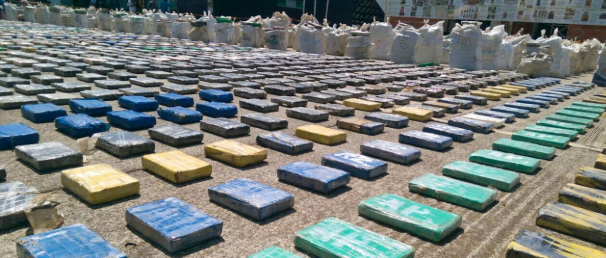


<i>


### Dataset: [Drug Seizures](https://www.kaggle.com/datasets/kindasomethin/drug-seizures-2019-2023)


|Parameter|Description|
|---|---|
|Shape|`11k rows, 9 columns`|
|Target Variable|`Kilograms`|
|Method:|`LinearRegression`, `RandomForestRegressor`, `XGBoost`|
|Extra Tools:|`RFE`, `make_pipeline`|

### Columns Descriptions


<strong style='color:red ; background-color:black;'> 

#### Disclosure: 
I used AI to convert the table from the kaggle dataset webpage into a markdown table.


#### Prompt:
 /paste Kaggle column descriptions/. 

 Could you put this into a markdown table for me? 

</strong>


#### Column Descriptions:

| Variable      | Description                              |
| ------------- | ---------------------------------------- |
| MedInc        | Median income in block group             |
| HouseAge      | Median house age in block group          |
| AveRooms      | Average number of rooms per household    |
| AveBedrms     | Average number of bedrooms per household |
| Population    | Block group population                   |
| AveOccup      | Average household size                   |
| Latitude      | Block group latitude                     |
| Longitude     | Block group longitude                    |
| MedHouseValue | Median house value                       |


#### Summary:

<i>

This is a notebook which let's me build some confidence with the a few things. First, I'll be using `make_pipeline` to run `StandardScaler` first and then run the model of my choice. Second, I'll be learning how to use `RFE` a scikit-learn function I recently watched a video about which was interesting. Here, I'll be testing it out on three different models: `LinearRegression`, `RandomForestRegression`, and `XGBoost`(new one for me)

[Youtube Video](https://www.youtube.com/watch?v=2lo8rVWytF8)
</i>

#### Results:

<i>

|`LinearRegression` Results| `RandomForestRegressor` Results| `XGBoost` Results|
|---|---|---|
|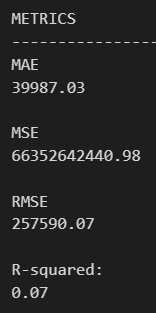|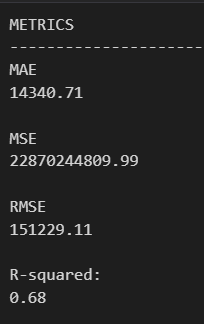|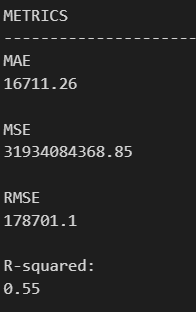|

</i>

<br>
<br>


---

## Code:

#### Imports and Data Loading

In [658]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn import metrics
import joblib

# Loading the dataset
df = pd.read_csv("datasets/drug_seizures.csv")
df.head(3)

,Region,SubRegion,Country,DrugGroup,DrugSubGroup,DrugName,Reference year,Kilograms,msCode
0,Africa,East Africa,Comoros,Any other drugs/substances,Other miscellaneous,Other drugs/substances,2023,45.0,COM
1,Africa,East Africa,Comoros,Cannabis-type drugs (excluding synthetic canna...,Cannabis herb (marijuana),Cannabis herb (marijuana),2023,2263.0,COM
2,Africa,East Africa,Comoros,Cannabis-type drugs (excluding synthetic canna...,Cannabis resin (hashish),Cannabis resin (hashish),2023,57.5,COM


---

### Data Cleaning

|Step|Description|
|---|---|
|1|<bold style="background:yellow;color:black;"> Data Cleaning </bold>|
|2| Transformation & Feature Engineering|
|3| ML Training & Metrics|

#### Checking the Shape

In [659]:
# Checking the rows and columns
df.shape

(11274, 9)

#### Handling Missing Values

In [660]:
# Checking for missing values
df.isna().sum()

# 76 / 11k rows. Neglible amount of rows to drop and it's not a timeseries.
# Let's drop them

Region             0
SubRegion          0
Country            0
DrugGroup          0
DrugSubGroup       0
DrugName           0
Reference year     0
Kilograms         76
msCode             0
dtype: int64

In [661]:
# Dropping Missing values.
df = df.dropna()

#### Checking Duplicates

In [662]:
# Checking for duplicates
df.duplicated().sum()

# Some duplicates as well, let's drop those too

np.int64(236)

In [663]:
# Dropping duplicates
df = df.drop_duplicates()

#### Dropping Columns

In [664]:
df.head(3)

,Region,SubRegion,Country,DrugGroup,DrugSubGroup,DrugName,Reference year,Kilograms,msCode
0,Africa,East Africa,Comoros,Any other drugs/substances,Other miscellaneous,Other drugs/substances,2023,45.0,COM
1,Africa,East Africa,Comoros,Cannabis-type drugs (excluding synthetic canna...,Cannabis herb (marijuana),Cannabis herb (marijuana),2023,2263.0,COM
2,Africa,East Africa,Comoros,Cannabis-type drugs (excluding synthetic canna...,Cannabis resin (hashish),Cannabis resin (hashish),2023,57.5,COM


#### Checking for Nonsensical Values

In [665]:
# Are there any weights under zero?
df[df["Kilograms"] < 0]

# Seems fine.

,Region,SubRegion,Country,DrugGroup,DrugSubGroup,DrugName,Reference year,Kilograms,msCode


In [666]:
# Are there any years before 2019 and after 2023?
# That wouldn't make sense since the Kaggle description
# Said it was in this range

df[
    (df["Reference year"] > 2023) |
    (df["Reference year"] < 2019)
]

# It's fine. Just making sure.

,Region,SubRegion,Country,DrugGroup,DrugSubGroup,DrugName,Reference year,Kilograms,msCode


#### Dropping Columns

In [667]:
# Dropping unneeded columns.
df = df.drop([
    "Region",
    "msCode"
    ], axis=1)          # 99% this will be multicollinear with Subregion

# I'm not dropping Subregion because they might still be statistically valid and not completely
# redundant.

#### Checking for Isolated Cases in Categorical Values

`Subregion`

In [668]:
# Checking value counts starting with the fewest counts.
df["SubRegion"].value_counts().reset_index().sort_values("count")

# No problems here.

,SubRegion,count
15,Caribbean,97
14,East Africa,129
13,South Asia,205
12,Southern Africa,217
11,North Africa,223
10,Central America,237
9,Eastern Europe,394
8,Central Asia and Transcaucasia,440
7,West and Central Africa,513
6,Near and Middle East/ South-West Asia,530


`Country`

In [669]:
# Checking value counts starting with the fewest counts.
df["Country"].value_counts().reset_index().sort_values("count")

# This is an issue, because there's way too few cases for these.
# Let's filter out any countries that have less than 10 cases.

,Country,count
163,Holy See,1
161,Seychelles,2
162,Timor-Leste,2
158,Angola,3
159,Democratic Republic of the Congo,3
...,...,...
4,Sweden,270
3,Switzerland,283
2,Argentina,297
1,Australia,374


In [670]:
# DISCLOSURE, I TOOK THIS FROM AI:

# PROMPT: I don't remember, it was a little while ago (maybe 3 months ago).
# I since have been using it as a copy-paste

# MODEL: ChatGPT 4.0

# WHY I KNOW IT WORKS:
# Well, since then I've actually learned a bit more about lambda filters.
# Since we're grouping entire values by country, that means it takes all the 
# rows as x for lambda. 

# Since we are taking the len(x), we're taking the number of rows and filtering
# it by greater than or equal to 10.

# Therefore, it works!

# ------------------------------------

# We'll use a groupby lambda to filter out any cases.

# We count the number of rows using len(x) by country.
# If the country is under 10, get out. 
df = df.groupby("Country").filter(lambda x: len(x) >= 10)
df.head(3)

,SubRegion,Country,DrugGroup,DrugSubGroup,DrugName,Reference year,Kilograms
9,East Africa,Kenya,Cannabis-type drugs (excluding synthetic canna...,Cannabis herb (marijuana),Cannabis herb (marijuana),2020,12911.00
10,East Africa,Kenya,Cannabis-type drugs (excluding synthetic canna...,Cannabis plants,Cannabis plants,2020,814.80
11,East Africa,Kenya,Cocaine-type,Cocaine,Cocaine hydrochloride,2020,0.35


`DrugGroup`

In [671]:
# Checking value counts starting with the fewest counts.
df["DrugGroup"].value_counts().reset_index().sort_values("count")

# That seems ok.

,DrugGroup,count
10,Solvents and Inhalants,17
9,Precursors,294
8,Any other drugs/substances,316
7,NPS,565
6,“Ecstasy”-type substances,669
5,Hallucinogens,776
4,Cocaine-type,933
3,Sedatives and tranquillizers,1053
2,Amphetamine-type stimulants (excluding “ecstasy”),1448
1,Cannabis-type drugs (excluding synthetic canna...,2144


`DrugsSubGroup`

In [672]:
# Checking value counts starting with the fewest counts.
df["DrugSubGroup"].value_counts().reset_index().sort_values("count")

# Same deal, not enough cases.

,DrugSubGroup,count
48,Aminoindanes,1
47,Opioids,1
46,Other/non-specified coca/cocaine-type drugs OR...,3
45,Tryptamines,4
42,Non-specified hallucinogens,6
43,Methaqualone,6
44,Other NPS,6
41,Piperazines,8
40,Substances not under int. control,10
39,Non-specified amphetamine-type stimulants,11


In [673]:
# We'll use a groupby lambda to filter out any cases.

# We count the number of rows using len(x) by country.
# If the country is under 10, get out. 
df = df.groupby("DrugSubGroup").filter(lambda x: len(x) >= 10)
df.head(3)

,SubRegion,Country,DrugGroup,DrugSubGroup,DrugName,Reference year,Kilograms
9,East Africa,Kenya,Cannabis-type drugs (excluding synthetic canna...,Cannabis herb (marijuana),Cannabis herb (marijuana),2020,12911.00
10,East Africa,Kenya,Cannabis-type drugs (excluding synthetic canna...,Cannabis plants,Cannabis plants,2020,814.80
11,East Africa,Kenya,Cocaine-type,Cocaine,Cocaine hydrochloride,2020,0.35


`DrugName`

In [674]:
# Now let's look at all the drug names.
df["DrugName"].value_counts().reset_index().sort_values("count")

# Lots of isolated cases that can't really be used for any statistical significance

,DrugName,count
144,Phenethylamine,1
145,MDEA,1
139,Non-specified,1
138,Adderall,1
148,Alpha-PHpP (PV8),1
...,...,...
4,Cannabis resin (hashish),468
3,Cocaine hydrochloride,513
2,Methamphetamine,542
1,Heroin,585


In [675]:
# We count the number of rows using len(x) by country.
# If the country is under 10, get out. 
df = df.groupby("DrugName").filter(lambda x: len(x) >= 10)
df.head(3)

# 10,566 rows left -- We're still fine.

,SubRegion,Country,DrugGroup,DrugSubGroup,DrugName,Reference year,Kilograms
9,East Africa,Kenya,Cannabis-type drugs (excluding synthetic canna...,Cannabis herb (marijuana),Cannabis herb (marijuana),2020,12911.00
10,East Africa,Kenya,Cannabis-type drugs (excluding synthetic canna...,Cannabis plants,Cannabis plants,2020,814.80
11,East Africa,Kenya,Cocaine-type,Cocaine,Cocaine hydrochloride,2020,0.35


#### Turning All Columns Into Numeric 

#### Categorical

In [676]:
# OneHotEncoder
# This turns all categorical columns into binary, separate columns.
categorical_columns = ["SubRegion","Country", "DrugGroup", "DrugSubGroup", "DrugName"]

for column in categorical_columns:
    encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
    one_hot_encoded = encoder.fit_transform(df[[column]]).astype(int)
    df = pd.concat([df.drop(columns=[column]), one_hot_encoded], axis=1)

# This is going to create A METRIC TON of columns. Which is by design.
# I picked this dataset to make sure RFE was actually useful.

# Anyways, here we're dropping one possible value.
# Since if all others column values are 0...
# This would be deductively be 1!
# (huh. Is not doing this a dataleak then?)
df = df.drop([
    "SubRegion_East Africa",
    "Country_Kenya",
    "DrugGroup_Cocaine-type",
    "DrugName_Cocaine hydrochloride"
], axis=1)

---

### Transformation & Feature Engineering

|Step|Description|
|---|---|
|1|Data Cleaning |
|2|<bold style="background:yellow;color:black;">  Transformation & Feature Engineering</bold>|
|3| ML Training & Metrics|

#### Checking the Distribution of the Target Variable

<Axes: xlabel='Kilograms', ylabel='Count'>

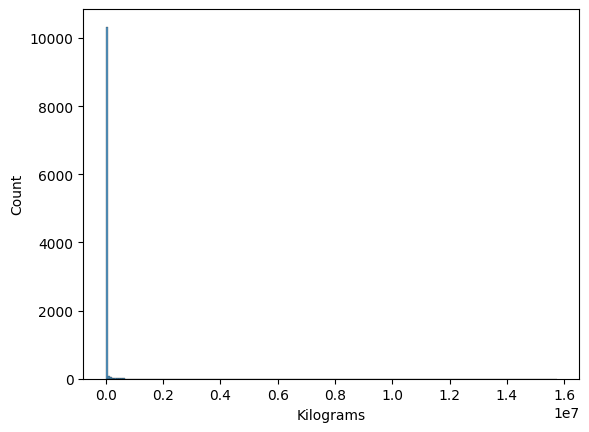

In [677]:
# Let's look at the distribution 
sns.histplot(df, x='Kilograms')

# StandardScaler might work well here. But it might not help the skew.

# Maybe Log1p or YeoJohnson? Let's see if I was right.

<i>
Oh dear, there must be some isolated case where A LOT. and I mean A LOT of drugs were seized. Let's figure out how much that is, I'm curious.

In [678]:
# Find the row with the highest amount of Kilograms seized
df['Kilograms'].max()


np.float64(15734375.8)

In [679]:
# Filtering out the row with the millions of Kilos
df[df['Kilograms'] > 15000000]

# That's a lot of illegal substance.

,Reference year,Kilograms,SubRegion_Australia and New Zealand,SubRegion_Caribbean,SubRegion_Central America,SubRegion_Central Asia and Transcaucasia,SubRegion_East and South-East Asia,SubRegion_Eastern Europe,SubRegion_Near and Middle East/ South-West Asia,SubRegion_North Africa,...,DrugName_Synthetic cannabinoids (Spice),DrugName_Synthetic cannabinoids (“Spice”),DrugName_Synthetic cannabinoids under international control,DrugName_Synthetic cathinones,"DrugName_Total ""ecstasy""-type substances (including the above, all other substances of this type and any unspecified/undistinguished quantities of substances of this type)","DrugName_Total amphetamine-type stimulants (ATS) (including the above, all other ATS, and any unspecified/undistinguished quantities of ATS)","DrugName_Total hallucinogens (including the above, all other hallucinogens, and any unspecified/undistinguished quantities of hallucinogens)","DrugName_Total sedatives and tranquillizers (including the above, all other sedatives and tranquillizers, and any unspecified/undistinguished quantities of sedatives and tranquillizers)",DrugName_Tramadol,DrugName_“Yaba”
6442,2023,15734375.8,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


#### Histplots -- What Transformation Works Best?

<i>

This part is creating a separate dataframe and is just an experimental play ground that answers this:

<strong style='color:orange ; background-color:black;'> What transformation works best?</strong>

We're not using this, it's just for visualization. Otherwise it would be a data-leak.

Text(0.5, 1.0, 'Log')

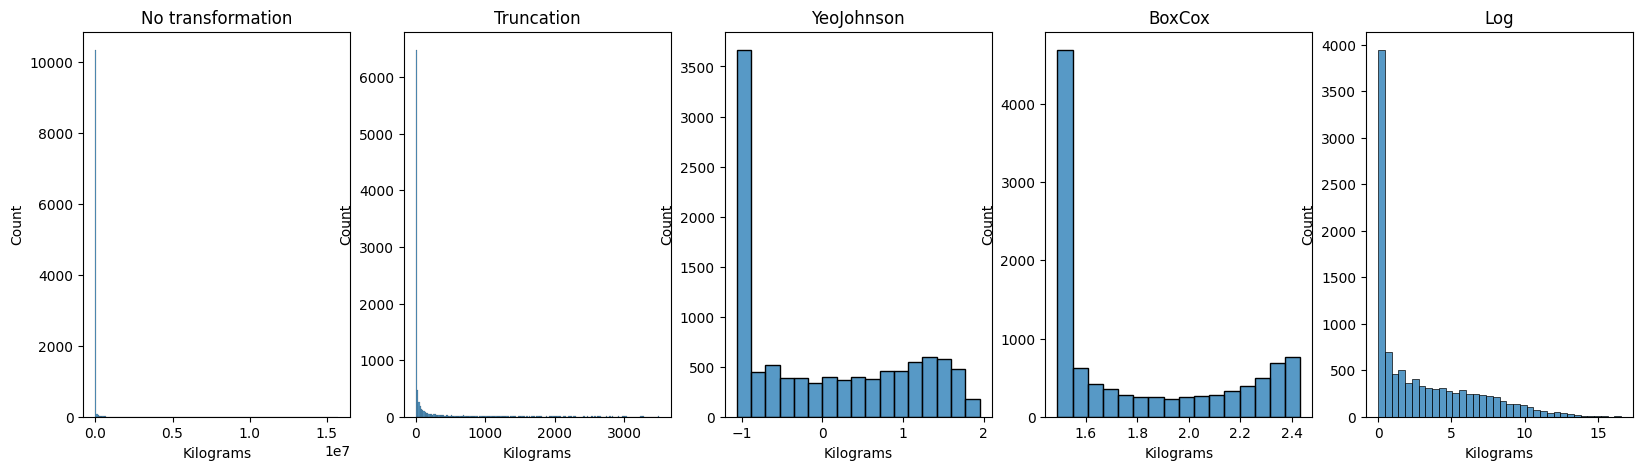

In [680]:
from sklearn.preprocessing import PowerTransformer
from scipy import stats
from sklearn.preprocessing import StandardScaler

# Let's just get rid of all of the outliers over 3 standard deviations out
# for the features AND the target variable. 
Y_TRUNC = .90


# Creating a new dataframe. We just want to see what works
df_copy = df.copy()

# Let's make a canvas, we put our plots here.
fig, axes = plt.subplots(1, 5, figsize=(20, 5))



# HISTPLOT 1 -- No transformation
sns.histplot(df_copy, x="Kilograms", ax=axes[0])


# HISTPLOT 2 -- Truncation

df_copy = df_copy[df_copy["Kilograms"] < df_copy["Kilograms"].quantile(Y_TRUNC)]

sns.histplot(df_copy, x="Kilograms", ax=axes[1])

# HISTPLOT 3 -- yeojohnson
pt = PowerTransformer(method='yeo-johnson')
df_copy_yeo = df.copy()
df_copy_yeo["Kilograms"] = pt.fit_transform(df_copy_yeo[["Kilograms"]])
sns.histplot(df_copy_yeo, x="Kilograms", ax=axes[2])

# HISTPLOT 4 -- boxcox 
df_copy_bc = df.copy()

df_copy_bc['Kilograms'], _ = stats.boxcox(df_copy_bc['Kilograms'] + 10) 
sns.histplot(df_copy_bc, x="Kilograms", ax=axes[3])

# HISTPLOT 5 -- Log
df_copy_log = df.copy()

df_copy_log['Kilograms'] = np.log1p(df_copy_log['Kilograms'])
sns.histplot(df_copy_log, x="Kilograms", ax=axes[4])



# TITLES
axes[0].set_title("No transformation")
axes[1].set_title("Truncation")
axes[2].set_title("YeoJohnson")
axes[3].set_title("BoxCox")
axes[4].set_title("Log")

<div style="border: 3px dashed white; padding: 10px; box-sizing: border-box;">

<i>

<h3>Observations</h3>

Let's pick YeoJohnson. It doesn't have a bi-modal distribution 

So, when we make the pipeline, we'll use column transformer on the target variable.

We are NOT DOING THIS TRANSFORMATION NOW. Or it will create a dataleak.

</div>

#### Checking the Distribution of the Numeric Features

<i>

We're checking if any potential X features have bad distributions. Luckily, we only have one possible bad distribution column

`Reference Year`

In [681]:
# Checking the distribution of `Reference Year`
df_copy["Reference year"].value_counts()

# Looks fine.

Reference year
2022    2067
2021    2003
2020    1918
2023    1871
2019    1650
Name: count, dtype: int64

### Feature Engineering 

#### RFE (Recursive Feature Elimination)

<i> Since we have a a lot of features (over 200 columns), we're going to use RFE to reduce the number of features that are noisy in the modeling portion here.

We can use RFE in every ML model(model-agnostic, the documentation calls it) by initializing the model as the estimator.

[Source](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.RFE.html)

We'll be using it in the model in the make_pipeline section.

---

### ML Training & Metrics

|Step|Description|
|---|---|
|1|Data Cleaning |
|2|Transformation & Feature Engineering|
|3|<bold style="background:yellow;color:black;">   ML Training & Metrics </bold>|

---

### ML Training & Metrics

<i>

Here, I'll be using RFE to select all of the features for me. The point of this whole notebook is to check to see how exactly RFE works. We'll be trying out a few different models.
`LinearRegression`, `RandomForestRegressor`, and `SVM`

<br>

At the end, I'll talk a bit about my thoughts and what I learned.

`LinearRegression`

In [682]:
from sklearn.pipeline import make_pipeline

# Constants
XY_SPLIT = 0.3

# Defining dependent, independent variables.
# Split dataset to Target variable and it's features as X, y.
X = df.drop("Kilograms", axis=1)
y = df["Kilograms"]

# train/test-split.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=XY_SPLIT, random_state=101)



# -- TRAINING & PREDICTION -- 

# Step 1: RFE, Select 90 of the best features optimized for
# Linear Regression
rfe = RFE(LinearRegression(), n_features_to_select=90)

X_train_selected = rfe.fit_transform(X_train, y_train)
X_test_selected = rfe.transform(X_test)

# Step 2: Run a make_pipeline. Using the chaining method 
# from Tuomas' snippet. 
pipeline = make_pipeline(
    StandardScaler(),
   LinearRegression()
)

# FULL DISCLOSURE: I USED AI 

# PROMPT: 
# y_test = pt.fit_transform(y_test)
# y_train = pt.fit_transform(y_train)
# Why is this not working?

# MODEL: ChatGPT

# WHY I THINK IT WORKS:
# The issue was that the shape was in a 1D model and needed to be 2D.
# This is a way to fix it using numpy, but I bet there's a pandas way
# to fix it too.

# Step 3: Transform Target Variable to yeo-johnson
# This requires us to reshape it from 1D to a 2D array (-1,1)
# And to do that, you need to convert to numpy.
y_train_transformed = pt.fit_transform(y_train.to_numpy().reshape(-1, 1))
y_train_transformed = pt.fit_transform(y_train.to_numpy().reshape(-1, 1))
# Alternatively, I could have created a ColumnTransformer, but for
# only one variable, that's completely not worth it. 

# Step 4: Initalize and fit the model.
pipeline.fit(X_train_selected, y_train)

# Step:5 Predict the data with the model.
predictions = pipeline.predict(X_test_selected)

# Step 6: Save the model using joblib
joblib.dump(pipeline, "models/ex1_extra1_linreg.pkl")

['models/ex1_extra1_linreg.pkl']

In [683]:
# -- CALCULATE METRICS -- 
mae = metrics.mean_absolute_error(y_test, predictions)
mse = metrics.mean_squared_error(y_test, predictions)
rmse = np.sqrt(metrics.mean_squared_error(y_test, predictions))
r_sq = metrics.r2_score(y_test, predictions)

# -- PRINT METRICS --
print("METRICS")
print("--------------------------")
print("MAE")
print(f"{round(mae,2)} \n")
print("MSE")
print(f"{round(mse,2)} \n")
print("RMSE")
print(f"{round(rmse,2)} \n")
print('R-squared:')
print(f"{round(r_sq,2)} \n")

METRICS
--------------------------
MAE
39987.03 

MSE
66352642440.98 

RMSE
257590.07 

R-squared:
0.07 



<i> Clearly not a linear relationship! Let's try the next one. We'll change RFE to optimize for RandomForestRegressor instead.

`RandomForestRegressor`

In [684]:
from sklearn.ensemble import RandomForestRegressor

# Step 1: RFE, Select 90 of the best features optimized for
# RandomForestRegressor
rfe = RFE(RandomForestRegressor(n_estimators=4), n_features_to_select=30, step=10)

X_train_selected = rfe.fit_transform(X_train, y_train)
X_test_selected = rfe.transform(X_test)

# Step 2: Run a make_pipeline. Using the chaining method 
# from Tuomas' snippet. 
pipeline = make_pipeline(
    StandardScaler(),
   RandomForestRegressor()
)

# Step 3: Transform Target Variable to yeo-johnson
# This requires us to reshape it from 1D to a 2D array (-1,1)
# And to do that, you need to convert to numpy.
y_train_transformed = pt.fit_transform(y_train.to_numpy().reshape(-1, 1))
y_train_transformed = pt.fit_transform(y_train.to_numpy().reshape(-1, 1))
# Alternatively, I could have created a ColumnTransformer, but for
# only one variable, that's completely not worth it. 

# Step 4: Initalize and fit the model.
pipeline.fit(X_train_selected, y_train)

# Step:5 Predict the data with the model.
predictions = pipeline.predict(X_test_selected)

# Step 6: Save the model using joblib
joblib.dump(pipeline, "models/ex1_extra1_rforest.pkl")

['models/ex1_extra1_rforest.pkl']

In [685]:
# -- CALCULATE METRICS -- 
mae = metrics.mean_absolute_error(y_test, predictions)
mse = metrics.mean_squared_error(y_test, predictions)
rmse = np.sqrt(metrics.mean_squared_error(y_test, predictions))
r_sq = metrics.r2_score(y_test, predictions)

# -- PRINT METRICS --
print("METRICS")
print("--------------------------")
print("MAE")
print(f"{round(mae,2)} \n")
print("MSE")
print(f"{round(mse,2)} \n")
print("RMSE")
print(f"{round(rmse,2)} \n")
print('R-squared:')
print(f"{round(r_sq,2)} \n")

METRICS
--------------------------
MAE
14131.68 

MSE
23567190629.33 

RMSE
153516.09 

R-squared:
0.67 



<i>

That's the best fit I've gotten so far. To think that us being off by ~14,000 Kg for a single seizure prediction would be an achievement! (Do I have a dataleak somewhere?)

`XGBoost`

In [686]:
import xgboost as xgb

# Step 1: RFE, Select 90 of the best features optimized for
# xgboost 
rfe = RFE(xgb.XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42      
), n_features_to_select=30, step=10)
# These hyperparameters kind of remind me of `CatBoostRegressor`!

X_train_selected = rfe.fit_transform(X_train, y_train)
X_test_selected = rfe.transform(X_test)

# Step 2: Run a make_pipeline. Using the chaining method 
# from Tuomas' snippet. 
pipeline = make_pipeline(
    StandardScaler(),

    xgb.XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42      
    )
)

# Step 3: Transform Target Variable to yeo-johnson
# This requires us to reshape it from 1D to a 2D array (-1,1)
# And to do that, you need to convert to numpy.
y_train_transformed = pt.fit_transform(y_train.to_numpy().reshape(-1, 1))
y_train_transformed = pt.fit_transform(y_train.to_numpy().reshape(-1, 1))
# Alternatively, I could have created a ColumnTransformer, but for
# only one variable, that's completely not worth it. 

# Step 4: Initalize and fit the model.
pipeline.fit(X_train_selected, y_train)

# Step:5 Predict the data with the model.
predictions = pipeline.predict(X_test_selected)

# Step 6: Save the model using joblib
joblib.dump(pipeline, "models/ex1_extra1_rforest.pkl")

['models/ex1_extra1_rforest.pkl']

In [687]:
# -- CALCULATE METRICS -- 
mae = metrics.mean_absolute_error(y_test, predictions)
mse = metrics.mean_squared_error(y_test, predictions)
rmse = np.sqrt(metrics.mean_squared_error(y_test, predictions))
r_sq = metrics.r2_score(y_test, predictions)

# -- PRINT METRICS --
print("METRICS")
print("--------------------------")
print("MAE")
print(f"{round(mae,2)} \n")
print("MSE")
print(f"{round(mse,2)} \n")
print("RMSE")
print(f"{round(rmse,2)} \n")
print('R-squared:')
print(f"{round(r_sq,2)} \n")

METRICS
--------------------------
MAE
16711.26 

MSE
31934084368.85 

RMSE
178701.1 

R-squared:
0.55 



<i>

Quite a few hyperparameter options to choose from. It would be pretty neat to make a loop to benchmark each of these options through some ranges to see what works best (and then log that in `mlflow`)



---

## Personal Analysis

<i>
(Feel free to skip it if it's too much -- This is mainly for me to write down what I've learned so I remember it.)

There's quite a bit that I learned this notebook. I'll now go point-by-point to explain what I've learned.

### Lesson One
 is that `XGBoost` has a ton of hyperparameters and I need to look into it a bit to understand the use-case for them. parameters like `max_depth` or `n_estimators` makes sense to me, but I want to develop an intuition behind choosing a value justifying it (even if it's an estimate). I'm pretty sure stuff like this will get discussed in the Advanced Data Analytics courses later in the program, but it's probably good to at least have an initial intuition about it. 

### Lesson Two
I think the `RFE` was a success. It was able to eliminate over 150 features and still get a reasonably good fit. I found the model-agnostic approach really nice (any model can use `RFE`). The way `RFE` works, is that it contiuously runs the model on the dataset and each time, it ranks the features by importance(weight), throws some features away, and repeats the process. The tradeoff is that this can be a slow process. If you use `RFE`, for example, on `RandomForestRegressor(n_estimators=100)`, you can expect to be there for a long time since it's going to run 100 estimators a high number of times. Another risk is overfitting. This was expected for me, and it could be that these results are a bit overfitted already. In my next notebook -- I'll try to do a training/test/validation and make a plot that shows whether overfit exists.

### Lesson Three
Third, I figured out that `StandardScaler()` is a good approach to handling big number differences in both features and the target variable. It has really helped with the volatility for how it handled the feature weights for the numeric features. I'll keep that in mind in the future.

### Lesson Four
Four, `make_pipeline` is powerful. `make_pipeline` let's you preprocess and fit a model all in one, but without the nuance of transforming select columns using `ColumnTransformer` in ex1_01_main.ipynb. This is really useful for when you're already running processes for EVERY feature in the pipeline. 

---

</i>

## Pipeline & ColumnTransformer Method
Transform each feature individually

```py

# METHOD 1
# -- Pipeline & ColumnTransformer Method --

# Allows me to select what transformations I want PER FEATURE
preprocessor = ColumnTransformer(transformers=[
    ('cbrt', FunctionTransformer(np.cbrt), ['bldgarea', "unitstotal"]),
    ('log', FunctionTransformer(np.log1p), ['lotarea']),
    ("boxcox", PowerTransformer(method="box-cox"), ["unitsres"]),
], remainder='passthrough')

# This runs the model
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LinearRegression())
])
```

---

## make_pipeline method
Transform all features at once.

<br>

```py
# METHOD 2
# -- make_pipeline method --

# Short-hand version of the above, where I can preprocess ALL FEATURES at once.
pipeline = make_pipeline(
    StandardScaler(),

    xgb.XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42      
    )
)
```


---

## Sources:


[RFE](https://www.geeksforgeeks.org/machine-learning/recursive-feature-elimination/)

[XGBoost](https://xgboost.readthedocs.io/en/release_3.2.0/tutorials/index.html)